# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibly one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [3]:
import random


class Card:
    def __init__(self, rank, suit=None):
        self.rank = rank
        self.suit = suit

    @property
    def is_plastic(self):
        return self.rank == "Plastic"

    def __str__(self):
        if self.is_plastic:
            return "Plastic card"
        return f"{self.rank} of {self.suit}"


class Deck:
    def __init__(self, num_decks=6):
        if not isinstance(num_decks, int) or num_decks < 1:
            raise ValueError("num decks must be a positive integer")

        self.num_decks = num_decks
        self.cards = []
        self.shuffle_needed = False
        self.shuffle()

    def shuffle(self):
        suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
        ranks = [
            "2", "3", "4", "5", "6", "7", "8", "9", "10",
            "Jack", "Queen", "King", "Ace"
        ]

        self.cards = [
            Card(rank, suit)
            for _ in range(self.num_decks)
            for suit in suits
            for rank in ranks
        ]

        random.shuffle(self.cards)

        position = random.randint(0, len(self.cards))
        self.cards.insert(position, Card("Plastic"))
        self.shuffle_needed = False

    def draw(self):
        while self.cards:
            card = self.cards.pop()

            if card.is_plastic:
                self.shuffle_needed = True
                continue  # The plastic card does not go into a hand.

            return card

        self.shuffle_needed = True
        raise RuntimeError("No cards remain. Reshuffle before a new round.")

    def start_round(self):
        if self.shuffle_needed or not self.cards:
            self.shuffle()

In [5]:
deck = Deck(num_decks=6)

print("Total cards:", len(deck.cards)) 

deck.start_round()

for _ in range(5):
    print(deck.draw())

print("Shuffle before next round:", deck.shuffle_needed)

Total cards: 313
6 of Diamonds
6 of Clubs
8 of Spades
10 of Spades
Queen of Spades
Shuffle before next round: False


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [8]:
class Hand:
    cards: list[Card]

    def __init__(self):
        pass

    def add_card(self, card):
        pass

    def total(self) -> int:
        pass

    def is_blackjack(self) -> bool:
        pass

    def is_bust(self) -> bool:
        pass

    def clear(self):
        pass


class Player:
    name: str
    chips: float
    bet: float
    hand: Hand

    def __init__(self, name, chips=100):
        pass

    def place_bet(self, amount):
        pass

    def choose_action(self, dealer_card) -> str:
        pass

    def observe_card(self, card):
        pass

    def reset_count(self):
        pass

    def receive_payout(self, amount):
        pass

    def reset_hand(self):
        pass


class DealerPlayer(Player):
    def choose_action(self, dealer_card) -> str:
        pass


class HumanPlayer(Player):
    def choose_action(self, dealer_card) -> str:
        pass


class CountingPlayer(Player):
    running_count: int
    threshold: int

    def __init__(self, name, chips=100, threshold=0):
        pass

    def observe_card(self, card):
        pass

    def reset_count(self):
        pass

    def choose_action(self, dealer_card) -> str:
        pass


class BlackjackGame:
    deck: Deck
    dealer: DealerPlayer
    players: list[Player]
    verbose: bool

    def __init__(self, players, num_decks=6, verbose=False):
        pass

    def place_bets(self):
        pass

    def deal_initial_cards(self):
        pass

    def reveal_card(self, card):
        pass

    def play_turn(self, player):
        pass

    def settle_bets(self):
        pass

    def play_round(self):
        pass

    def simulate(self, rounds) -> list[dict]:
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [10]:
class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        if card.is_plastic:
            raise ValueError("A plastic card cannot go into a hand.")
        self.cards.append(card)

    def total(self):
        total = 0
        aces = 0

        for card in self.cards:
            if card.rank == "Ace":
                total += 11
                aces += 1
            elif card.rank in ("Jack", "Queen", "King"):
                total += 10
            else:
                total += int(card.rank)

        while total > 21 and aces:
            total -= 10
            aces -= 1

        return total

    def is_blackjack(self):
        return len(self.cards) == 2 and self.total() == 21

    def is_bust(self):
        return self.total() > 21

    def clear(self):
        self.cards.clear()

    def __str__(self):
        return ", ".join(str(card) for card in self.cards)


class Player:
    def __init__(self, name, chips=100):
        if chips < 0:
            raise ValueError("Chips cannot be negative.")

        self.name = name
        self.chips = float(chips)
        self.bet = 0
        self.hand = Hand()

    def place_bet(self, amount):
        if not 0 < amount <= self.chips:
            raise ValueError("The bet must be positive and affordable.")

        self.bet = amount
        self.chips -= amount

    def choose_action(self, dealer_card):
        raise NotImplementedError("Use a player subclass.")

    def observe_card(self, card):
        pass

    def reset_count(self):
        pass

    def receive_payout(self, amount):
        self.chips += amount

    def reset_hand(self):
        self.hand.clear()
        self.bet = 0


class DealerPlayer(Player):
    def choose_action(self, dealer_card):
        return "hit" if self.hand.total() < 17 else "stand"


class HumanPlayer(Player):
    def choose_action(self, dealer_card):
        while True:
            action = input(
                f"\n{self.name}: {self.hand} "
                f"(total {self.hand.total()})\n"
                f"Dealer shows {dealer_card}. "
                "Hit or stand? [h/s]: "
            ).strip().lower()

            if action in ("h", "hit"):
                return "hit"
            if action in ("s", "stand"):
                return "stand"

            print("Please enter h or s.")


class BlackjackGame:
    def __init__(self, players, num_decks=6, verbose=False):
        self.players = list(players)

        if not self.players:
            raise ValueError("Add at least one player.")

        if len({p.name for p in self.players}) != len(self.players):
            raise ValueError("Each player needs a unique name.")

        if 22 * (len(self.players) + 1) > 52 * num_decks:
            raise ValueError("Use more decks for this many players.")

        self.deck = Deck(num_decks)
        self.dealer = DealerPlayer("Dealer", chips=0)
        self.verbose = verbose
        self.active_players = []

    def place_bets(self):
        self.active_players = [
            p for p in self.players if p.chips > 0
        ]

        for player in self.active_players:
            player.place_bet(min(10, player.chips))

    def reveal_card(self, card):
        for player in self.players:
            player.observe_card(card)

        if self.verbose:
            print(f"Visible card: {card}")

    def deal_initial_cards(self):
        for deal_number in range(2):
            for player in self.active_players:
                card = self.deck.draw()
                player.hand.add_card(card)
                self.reveal_card(card)

            card = self.deck.draw()
            self.dealer.hand.add_card(card)

            if deal_number == 0:
                self.reveal_card(card)


    def play_turn(self, player):
        upcard = self.dealer.hand.cards[0]

        while player.hand.total() < 21:
            action = player.choose_action(upcard)

            if action == "stand":
                break

            if action != "hit":
                raise ValueError("Actions must be 'hit' or 'stand'.")

            card = self.deck.draw()
            player.hand.add_card(card)
            self.reveal_card(card)

        if self.verbose:
            print(
                f"{player.name}: {player.hand} "
                f"({player.hand.total()})"
            )

    def settle_bets(self):
        results = {}
        dealer_total = self.dealer.hand.total()
        dealer_blackjack = self.dealer.hand.is_blackjack()

        for player in self.active_players:
            hand = player.hand
            bet = player.bet

            if hand.is_bust():
                outcome, payout = "loss", 0

            elif dealer_blackjack:
                if hand.is_blackjack():
                    outcome, payout = "push", bet
                else:
                    outcome, payout = "loss", 0

            elif hand.is_blackjack():
                outcome, payout = "blackjack", 2.5 * bet

            elif (
                self.dealer.hand.is_bust()
                or hand.total() > dealer_total
            ):
                outcome, payout = "win", 2 * bet

            elif hand.total() == dealer_total:
                outcome, payout = "push", bet

            else:
                outcome, payout = "loss", 0

            player.receive_payout(payout)

            results[player.name] = {
                "outcome": outcome,
                "net_winnings": payout - bet,
                "chips": player.chips,
            }

            player.bet = 0

            if self.verbose:
                print(
                    f"{player.name}: {outcome}; "
                    f"chips = {player.chips:g}"
                )

        return results

    def play_round(self):
        funded = [p for p in self.players if p.chips > 0]

        if not funded:
            return {}

        for player in self.players + [self.dealer]:
            player.reset_hand()

        remaining = sum(
            not card.is_plastic for card in self.deck.cards
        )
        reserve = 22 * (len(funded) + 1)

        if self.deck.shuffle_needed or remaining < reserve:
            self.deck.shuffle()

            for player in self.players:
                player.reset_count()

            if self.verbose:
                print("Deck shuffled; counts reset.")

        self.place_bets()
        self.deal_initial_cards()

        if not self.dealer.hand.is_blackjack():
            for player in self.active_players:
                self.play_turn(player)

        self.reveal_card(self.dealer.hand.cards[1])

        if not self.dealer.hand.is_blackjack() and any(
            not p.hand.is_bust() and not p.hand.is_blackjack()
            for p in self.active_players
        ):
            self.play_turn(self.dealer)

        elif self.verbose:
            print(
                f"Dealer: {self.dealer.hand} "
                f"({self.dealer.hand.total()})"
            )

        return self.settle_bets()

    def simulate(self, rounds):
        history = []

        for _ in range(rounds):
            results = self.play_round()

            if not results:
                break

            history.append(results)

        return history

In [11]:
human = HumanPlayer("You", chips=100)

game = BlackjackGame(
    players=[human],
    num_decks=6,
    verbose=True
)

results = game.play_round()
print(results)

Visible card: 5 of Spades
Visible card: 5 of Diamonds
Visible card: Ace of Hearts



You: 5 of Spades, Ace of Hearts (total 16)
Dealer shows 5 of Diamonds. Hit or stand? [h/s]:  s


You: 5 of Spades, Ace of Hearts (16)
Visible card: 8 of Clubs
Visible card: 8 of Hearts
Dealer: 5 of Diamonds, 8 of Clubs, 8 of Hearts (21)
You: loss; chips = 90
{'You': {'outcome': 'loss', 'net_winnings': -10, 'chips': 90.0}}


5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [13]:
import random

random.seed(42)

players = [
    DealerPlayer("Computer 1", chips=100),
    DealerPlayer("Computer 2", chips=100),
    DealerPlayer("Computer 3", chips=100),
]

game = BlackjackGame(
    players=players,
    num_decks=6,
    verbose=True
)

starting_chips = {
    player.name: player.chips
    for player in players
}

history = []

for round_number in range(1, 6):
    print(f"\n{'=' * 45}")
    print(f"ROUND {round_number}")
    print(f"{'=' * 45}")

    chips_before = {
        player.name: player.chips
        for player in players
    }

    results = game.play_round()
    history.append(results)

    for player in players:
        result = results[player.name]

        assert player.chips >= 0
        assert player.chips == (
            chips_before[player.name] + result["net_winnings"]
        )

print("\nFINAL RESULTS")
print("-" * 45)

for player in players:
    net_change = player.chips - starting_chips[player.name]

    print(
        f"{player.name}: "
        f"{player.chips:.1f} chips "
        f"(net change: {net_change:+.1f})"
    )

print("All five rounds completed. Chip-balance checks passed.")


ROUND 1
Visible card: 7 of Hearts
Visible card: Ace of Hearts
Visible card: Queen of Clubs
Visible card: 10 of Diamonds
Visible card: Queen of Hearts
Visible card: 8 of Diamonds
Visible card: 2 of Hearts
Computer 1: 7 of Hearts, Queen of Hearts (17)
Computer 2: Ace of Hearts, 8 of Diamonds (19)
Visible card: 7 of Spades
Computer 3: Queen of Clubs, 2 of Hearts, 7 of Spades (19)
Visible card: 8 of Diamonds
Dealer: 10 of Diamonds, 8 of Diamonds (18)
Computer 1: loss; chips = 90
Computer 2: win; chips = 110
Computer 3: win; chips = 110

ROUND 2
Visible card: 5 of Spades
Visible card: 10 of Hearts
Visible card: 5 of Diamonds
Visible card: 4 of Diamonds
Visible card: 10 of Spades
Visible card: 9 of Hearts
Visible card: 4 of Diamonds
Visible card: 2 of Diamonds
Computer 1: 5 of Spades, 10 of Spades, 2 of Diamonds (17)
Computer 2: 10 of Hearts, 9 of Hearts (19)
Visible card: 3 of Clubs
Visible card: Queen of Spades
Computer 3: 5 of Diamonds, 4 of Diamonds, 3 of Clubs, Queen of Spades (22)
Vis

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [14]:
class CountingPlayer(Player):
    def __init__(self, name, chips=100, threshold=0):
        super().__init__(name, chips)
        self.running_count = 0
        self.threshold = threshold

    def observe_card(self, card):
        if card.is_plastic:
            return

        if card.rank in ("2", "3", "4", "5", "6"):
            self.running_count += 1

        elif card.rank in ("10", "Jack", "Queen", "King", "Ace"):
            self.running_count -= 1


    def reset_count(self):
        self.running_count = 0

    def choose_action(self, dealer_card):

        if self.hand.total() >= 21:
            return "stand"

        if self.running_count < self.threshold:
            return "hit"

        return "stand"

In [16]:
counter = CountingPlayer("Counter", chips=100, threshold=0)

for rank in ["2", "6", "8", "10", "King", "Ace"]:
    counter.observe_card(Card(rank, "Hearts"))

counter.hand.add_card(Card("10", "Clubs"))
counter.hand.add_card(Card("6", "Diamonds"))

print("Running count:", counter.running_count)
print("Action:", counter.choose_action(Card("9", "Spades")))

counter.reset_count()
print("Count after shuffle:", counter.running_count)

Running count: -1
Action: hit
Count after shuffle: 0


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [17]:
import random

random.seed(42)

starting_chips = 100

counter = CountingPlayer(
    "Counting Player",
    chips=starting_chips,
    threshold=0
)

players = [
    counter,
    DealerPlayer("Computer 1", chips=starting_chips),
    DealerPlayer("Computer 2", chips=starting_chips),
    DealerPlayer("Computer 3", chips=starting_chips),
]

game = BlackjackGame(
    players=players,
    num_decks=6,
    verbose=False
)

history = []

for round_number in range(1, 51):
    if counter.chips <= 0:
        break

    results = game.play_round()
    history.append(results)

winnings = counter.chips - starting_chips

print(f"Rounds played: {len(history)}")
print(f"Counting threshold: {counter.threshold}")
print(f"Starting chips: {starting_chips}")
print(f"Final chips: {counter.chips:.1f}")
print(f"Net winnings: {winnings:+.1f}")

if counter.chips <= 0:
    print("The counting player ran out of chips.")

print("Final balances:")
for player in players:
    print(f"{player.name}: {player.chips:.1f} chips")

Rounds played: 50
Counting threshold: 0
Starting chips: 100
Final chips: 30.0
Net winnings: -70.0
Final balances:
Counting Player: 30.0 chips
Computer 1: 50.0 chips
Computer 2: 0.0 chips
Computer 3: 0.0 chips


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probability of net winning or losing after 50 rounds?


Games simulated: 100
Total rounds played: 2529
Average final chips: 2.70
Average net winnings per game: -97.30
Average net winnings per round: -3.8474
Standard deviation of round winnings: 9.2684
Standard deviation of game winnings: 11.6866
Estimated probability of net profit: 0.0%
Estimated probability of net loss: 100.0%
Estimated probability of breaking even: 0.0%


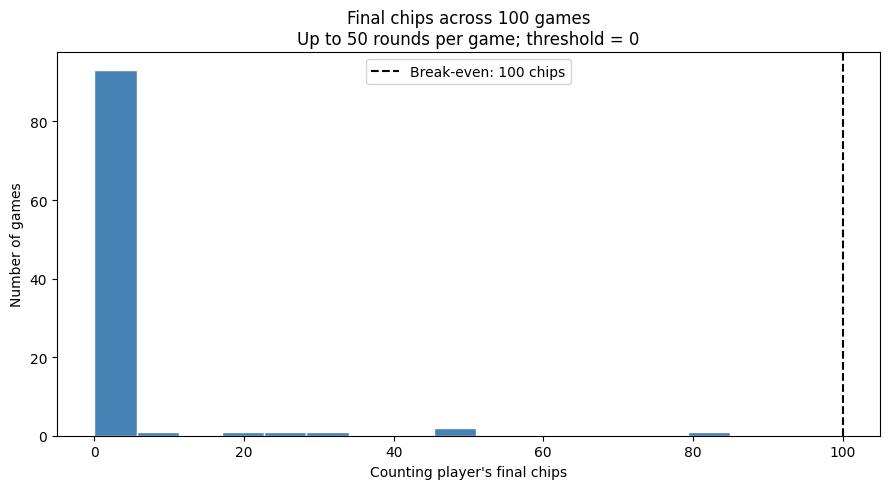

In [18]:
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)

number_of_games = 100
maximum_rounds = 50
starting_chips = 100
threshold = 0

winnings = []       
round_profits = []
round_counts = []

for game_number in range(number_of_games):
    counter = CountingPlayer(
        "Counting Player",
        chips=starting_chips,
        threshold=threshold
    )

    players = [
        counter,
        DealerPlayer("Computer 1", chips=starting_chips),
        DealerPlayer("Computer 2", chips=starting_chips),
        DealerPlayer("Computer 3", chips=starting_chips),
    ]

    game = BlackjackGame(
        players=players,
        num_decks=6,
        verbose=False
    )

    rounds_played = 0

    for _ in range(maximum_rounds):
        if counter.chips <= 0:
            break

        results = game.play_round()

        round_profits.append(
            results[counter.name]["net_winnings"]
        )
        rounds_played += 1

    winnings.append(counter.chips)
    round_counts.append(rounds_played)

final_chips = np.array(winnings)
net_winnings = final_chips - starting_chips

average_per_round = np.mean(round_profits)

std_per_round = np.std(round_profits, ddof=1)
std_per_game = np.std(net_winnings, ddof=1)

probability_win = np.mean(net_winnings > 0)
probability_loss = np.mean(net_winnings < 0)
probability_even = np.mean(net_winnings == 0)

print(f"Games simulated: {number_of_games}")
print(f"Total rounds played: {sum(round_counts)}")
print(f"Average final chips: {np.mean(final_chips):.2f}")
print(f"Average net winnings per game: {np.mean(net_winnings):+.2f}")
print(f"Average net winnings per round: {average_per_round:+.4f}")
print(f"Standard deviation of round winnings: {std_per_round:.4f}")
print(f"Standard deviation of game winnings: {std_per_game:.4f}")
print(f"Estimated probability of net profit: {probability_win:.1%}")
print(f"Estimated probability of net loss: {probability_loss:.1%}")
print(f"Estimated probability of breaking even: {probability_even:.1%}")

plt.figure(figsize=(9, 5))

plt.hist(
    winnings,
    bins=15,
    color="steelblue",
    edgecolor="white"
)

plt.axvline(
    starting_chips,
    color="black",
    linestyle="--",
    label=f"Break-even: {starting_chips} chips"
)

plt.title(
    f"Final chips across {number_of_games} games\n"
    f"Up to {maximum_rounds} rounds per game; threshold = {threshold}"
)
plt.xlabel("Counting player's final chips")
plt.ylabel("Number of games")
plt.legend()
plt.tight_layout()
plt.show()

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

Threshold  Final chips   Net/round    SD/game   Profit %    Loss %    Even %
      -20        31.25     -1.7370      48.67      12.0%     87.0%      1.0%
      -10        29.15     -1.8242      42.16       9.0%     89.0%      2.0%
       -5        18.20     -2.3703      38.18       4.0%     95.0%      1.0%
       -2         6.40     -3.1441      20.13       0.0%    100.0%      0.0%
        0         4.95     -3.4488      16.37       0.0%    100.0%      0.0%
        2         0.40     -4.3080       2.90       0.0%    100.0%      0.0%
        5         0.30     -5.4097       3.00       0.0%    100.0%      0.0%
       10         0.00     -6.1843       0.00       0.0%    100.0%      0.0%
       20         0.00     -6.5104       0.00       0.0%    100.0%      0.0%

Best tested threshold: -20
Average net winnings per round: -1.7370
Standard deviation of round winnings: 9.8290


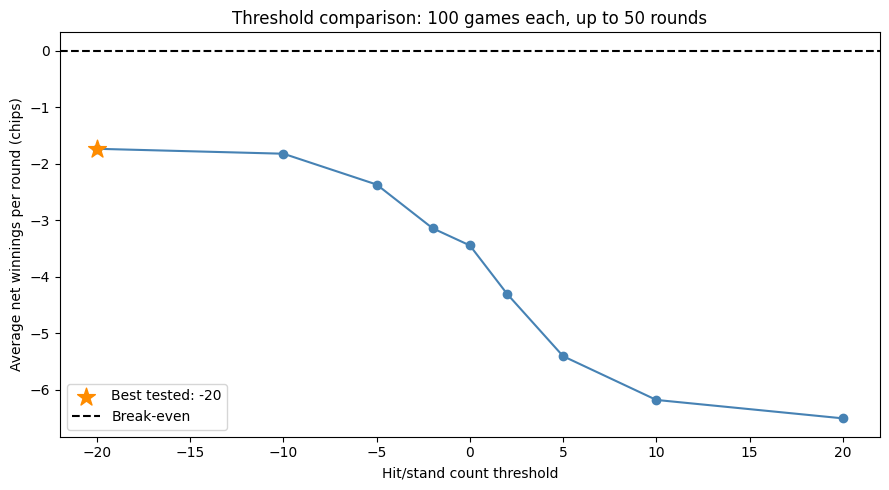

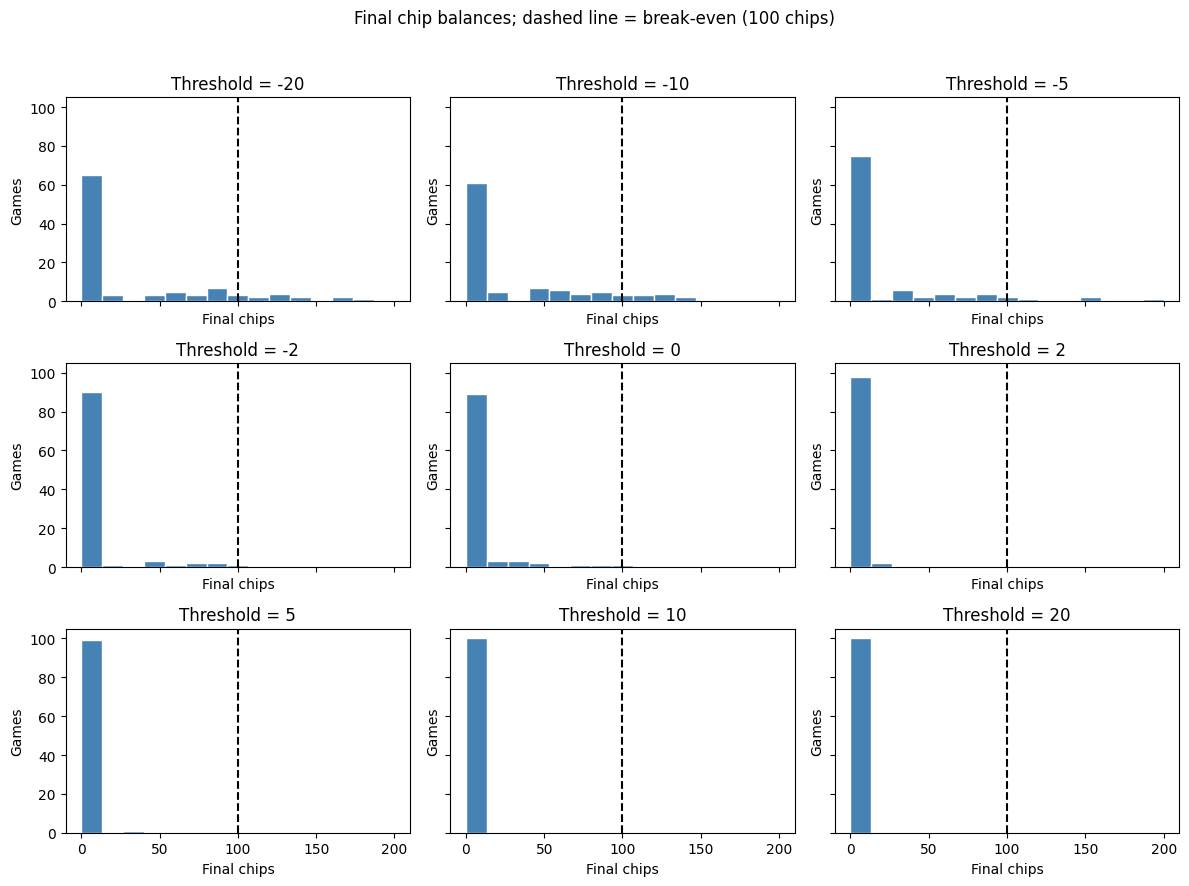

In [19]:
import random
import numpy as np
import matplotlib.pyplot as plt

thresholds = [-20, -10, -5, -2, 0, 2, 5, 10, 20]
number_of_games = 100
maximum_rounds = 50
starting_chips = 100


def evaluate_threshold(threshold):
    final_balances = []
    round_profits = []

    for game_number in range(number_of_games):
        random.seed(42 + game_number)

        counter = CountingPlayer(
            "Counter",
            chips=starting_chips,
            threshold=threshold
        )

        players = [
            counter,
            DealerPlayer("Computer 1", chips=starting_chips),
            DealerPlayer("Computer 2", chips=starting_chips),
            DealerPlayer("Computer 3", chips=starting_chips),
        ]

        game = BlackjackGame(
            players,
            num_decks=6,
            verbose=False
        )

        for _ in range(maximum_rounds):
            if counter.chips <= 0:
                break

            result = game.play_round()[counter.name]
            round_profits.append(result["net_winnings"])

        final_balances.append(counter.chips)

    final_balances = np.array(final_balances)
    net_winnings = final_balances - starting_chips

    return {
        "threshold": threshold,
        "final_balances": final_balances,
        "average_final_chips": np.mean(final_balances),
        "average_per_round": np.mean(round_profits),
        "std_per_round": np.std(round_profits, ddof=1),
        "std_per_game": np.std(net_winnings, ddof=1),
        "probability_win": np.mean(net_winnings > 0),
        "probability_loss": np.mean(net_winnings < 0),
        "probability_even": np.mean(net_winnings == 0),
    }


results_by_threshold = [
    evaluate_threshold(t) for t in thresholds
]

print(
    f"{'Threshold':>9} {'Final chips':>12} {'Net/round':>11} "
    f"{'SD/game':>10} {'Profit %':>10} {'Loss %':>9} {'Even %':>9}"
)

for result in results_by_threshold:
    print(
        f"{result['threshold']:>9} "
        f"{result['average_final_chips']:>12.2f} "
        f"{result['average_per_round']:>+11.4f} "
        f"{result['std_per_game']:>10.2f} "
        f"{result['probability_win']:>10.1%} "
        f"{result['probability_loss']:>9.1%} "
        f"{result['probability_even']:>9.1%}"
    )

best = max(
    results_by_threshold,
    key=lambda result: result["average_per_round"]
)

print(f"\nBest tested threshold: {best['threshold']}")
print(
    f"Average net winnings per round: "
    f"{best['average_per_round']:+.4f}"
)
print(
    f"Standard deviation of round winnings: "
    f"{best['std_per_round']:.4f}"
)

plt.figure(figsize=(9, 5))

plt.plot(
    thresholds,
    [r["average_per_round"] for r in results_by_threshold],
    marker="o",
    color="steelblue"
)

plt.scatter(
    best["threshold"],
    best["average_per_round"],
    marker="*",
    s=180,
    color="darkorange",
    zorder=3,
    label=f"Best tested: {best['threshold']}"
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    label="Break-even"
)

plt.xlabel("Hit/stand count threshold")
plt.ylabel("Average net winnings per round (chips)")
plt.title("Threshold comparison: 100 games each, up to 50 rounds")
plt.legend()
plt.tight_layout()
plt.show()

all_balances = np.concatenate([
    r["final_balances"] for r in results_by_threshold
])

bins = np.linspace(
    0,
    max(starting_chips, all_balances.max()) + 10,
    16
)

fig, axes = plt.subplots(
    3, 3,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)

for ax, result in zip(axes.flat, results_by_threshold):
    ax.hist(
        result["final_balances"],
        bins=bins,
        color="steelblue",
        edgecolor="white"
    )
    ax.axvline(starting_chips, color="black", linestyle="--")
    ax.set_title(f"Threshold = {result['threshold']}")
    ax.set_xlabel("Final chips")
    ax.set_ylabel("Games")

fig.suptitle(
    "Final chip balances; dashed line = break-even (100 chips)"
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [20]:
import random


class SimplePlayer(Player):
    def choose_action(self, dealer_card):
        return "hit" if self.hand.total() < 16 else "stand"


def test_strategy(player_type, **settings):
    total_winnings = 0
    total_rounds = 0

    for game_number in range(100):
        random.seed(42 + game_number)

        player = player_type("Test Player", chips=100, **settings)

        game = BlackjackGame(
            players=[
                player,
                DealerPlayer("Computer 1", chips=100),
                DealerPlayer("Computer 2", chips=100),
                DealerPlayer("Computer 3", chips=100),
            ],
            num_decks=6,
            verbose=False
        )

        for _ in range(50):
            if player.chips <= 0:
                break

            game.play_round()
            total_rounds += 1

        total_winnings += player.chips - 100

    return total_winnings / total_rounds


counting_average = test_strategy(
    CountingPlayer,
    threshold=best["threshold"]
)

simple_average = test_strategy(SimplePlayer)
difference = simple_average - counting_average

print(f"Counting strategy: {counting_average:+.3f} chips per round")
print(f"Simple strategy:   {simple_average:+.3f} chips per round")
print(f"Change:            {difference:+.3f} chips per round")

Counting strategy: -1.737 chips per round
Simple strategy:   -0.525 chips per round
Change:            +1.212 chips per round
